# Курсов проект по дисциплината
„Планиране на експеримента“

## Тенчо Гюлтенов Бостанджиев - вариант V15

**Фак. № 471223079 | Група 76**

Това е Вашето индивидуално задание. Работите само върху файловете на варианта, разпределен по реда на списъка. Задачата е интегрирана и включва последователни етапи от всички 7 теми от конспекта: почистване на данни, разпределения, корелация, извадки, моделиране, прогнозиране и оптимизация.

## 1. Данни за Вашия вариант

Код на варианта: V15

Контекст: Производствена клетка - електроенергийно натоварване - подвариант C

Фактор z_t: Външна среда / товарен индекс

Файлове за работа: student_data/V15_raw.csv и student_data/V15_future.csv

Структура на входните файлове: Vxx_raw.csv съдържа t, x_norm, z_factor, y_raw; Vxx_future.csv съдържа t, x_norm, z_factor.

Размер и особености на данните: 120 наблюдения за t = 1..120, хоризонт за прогноза t = 121..126, 4 липсващи стойности и 3 аномални точки в наблюдавания сигнал.

Важно ограничение: използвайте само student_data файловете за Вашия вариант. Не използвайте instructor_data, truth файлове или предварително известни параметри на генератора.

Специален акцент за Вашия вариант: В етап 4 обсъдете как изборът на 8 интервала влияе върху дисперсията и медианата.

## 2. Общата задача

Да се изгради напълно възпроизводим програмен проект, който започва от RAW данни, преминава през първична обработка, статистически анализ, моделиране и прогноза, и завършва с оптимизация на параметрите на избрания модел. Всички етапи трябва да бъдат реализирани с код; не се допуска решение, основано само на ръчна обработка в Excel или LibreOffice.

## Как да използвате този шаблон

Попълвайте TODO секциите с Вашия код и кратки пояснения. Не изтривайте ключовите клетки за импорти, зареждане на данните и финални проверки. Добра практика е след всяка по-съществена стъпка да добавяте кратки интерпретации в Markdown клетка.

In [1]:
# Основни библиотеки
import os
import sys
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

print("Python:", sys.version.split()[0])
print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)


Python: 3.11.9
NumPy : 2.4.4
Pandas: 3.0.2


In [2]:
# Помощни функции
def find_file(filename: str) -> Path:
    search_roots = [Path.cwd(), Path.cwd().parent]
    candidates = []
    for root in search_roots:
        candidates.extend([
            root / "student_data" / filename,
            root / filename,
            root / "data" / filename,
        ])
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Не откривам файла: {filename}. Проверете структурата на проекта.")


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(y_pred - y_true)


def empirical_edf(x):
    x = np.sort(np.asarray(x, dtype=float))
    p = np.arange(1, len(x) + 1) / len(x)
    return x, p


def ols_fit(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    residuals = y - y_hat
    return beta, y_hat, residuals


def standardize_from_train(train_series, full_series):
    mu = float(np.mean(train_series))
    sd = float(np.std(train_series, ddof=1))
    if sd == 0:
        raise ValueError("Стандартното отклонение е 0. Проверете регресора.")
    return (full_series - mu) / sd, mu, sd


def project_box(theta, lower, upper):
    theta = np.asarray(theta, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    return np.minimum(np.maximum(theta, lower), upper)


def fit_ar1_ols(residuals):
    r = np.asarray(residuals, dtype=float)
    r_prev = r[:-1]
    r_next = r[1:]
    phi = np.dot(r_prev, r_next) / np.dot(r_prev, r_prev)
    eta = r_next - phi * r_prev
    sigma_eta = np.std(eta, ddof=1)
    return phi, sigma_eta


In [3]:
ASSIGNMENT = {
    "student_name": 'Тенчо Гюлтенов Бостанджиев',
    "faculty_no": '471223079',
    "group": '76',
    "variant_code": 'V15',
    "scenario_title": 'Производствена клетка - електроенергийно натоварване - подвариант C',
    "factor_label": 'Външна среда / товарен индекс',
    "raw_file": 'V15_raw.csv',
    "future_file": 'V15_future.csv',
}

# Ако notebook-ът е стартиран от source/, връщаме се в основната директория,
# така че всички относителни пътища (CLEAN.csv, results/, ...) работят коректно.
if Path.cwd().name == "source":
    os.chdir("..")
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
SOURCE_DIR = PROJECT_ROOT / "source"
RESULTS_DIR.mkdir(exist_ok=True)
SOURCE_DIR.mkdir(exist_ok=True)

RAW_FILE = find_file(ASSIGNMENT["raw_file"])
FUTURE_FILE = find_file(ASSIGNMENT["future_file"])

raw_df = pd.read_csv(RAW_FILE)
future_df = pd.read_csv(FUTURE_FILE)

display(pd.DataFrame([ASSIGNMENT]))
display(raw_df.head())
display(future_df.head())

print("RAW shape   :", raw_df.shape)
print("FUTURE shape:", future_df.shape)


,student_name,faculty_no,group,variant_code,scenario_title,factor_label,raw_file,future_file
0,Тенчо Гюлтенов Бостанджиев,471223079,76,V15,Производствена клетка - електроенергийно натов...,Външна среда / товарен индекс,V15_raw.csv,V15_future.csv


,t,x_norm,z_factor,y_raw
0,1,0.008333,12.780207,92.081826
1,2,0.016667,13.701642,91.072325
2,3,0.025000,14.682057,90.800327
3,4,0.033333,15.679722,90.026581
4,5,0.041667,16.652152,89.307958


,t,x_norm,z_factor
0,121,1.008333,15.849962
1,122,1.016667,16.771396
2,123,1.025000,17.751812
3,124,1.033333,18.749476
4,125,1.041667,19.721906


RAW shape   : (120, 4)
FUTURE shape: (6, 3)


## Етап 0. Подготовка на проекта

Задание: Създайте проектова структура, импортирайте данните, проверете типовете на колоните, установете броя на редовете и запазете непроменено копие на RAW данните.

Документирайте с каква команда се стартира проектът.

Опишете използваните библиотеки и версията на езика/средата в README.txt.

Подгответе папки поне source/ и results/ за кода и резултатите.

In [4]:
# Потвърдете структурата и типовете на входните данни.
display(raw_df.dtypes.to_frame("dtype"))
display(future_df.dtypes.to_frame("dtype"))

# Непроменено копие на RAW данните.
raw_original = raw_df.copy(deep=True)

# Проверки
print("Липсващи стойности в RAW:")
display(raw_df.isna().sum().to_frame("count"))
print("Дублирани редове:", raw_df.duplicated().sum())
print("t е монотонно нарастваща колона:", raw_df["t"].is_monotonic_increasing)
print(f"Очакван брой редове: 120, наличен: {len(raw_df)}")
print(f"x_norm диапазон: [{raw_df['x_norm'].min():.6f}, {raw_df['x_norm'].max():.6f}]")
print(f"z_factor диапазон: [{raw_df['z_factor'].min():.4f}, {raw_df['z_factor'].max():.4f}]")
print(f"y_raw диапазон: [{raw_df['y_raw'].min():.4f}, {raw_df['y_raw'].max():.4f}]")

# README.txt
NB_NAME = "15 - V15 - Тенчо Гюлтенов Бостанджиев - шаблон.ipynb"
readme_lines = [
    "Курсов проект по Планиране на експеримента - V15",
    "===================================================",
    "Студент : Тенчо Гюлтенов Бостанджиев",
    "Фак. №  : 471223079",
    "Група   : 76",
    "Вариант : V15 - Производствена клетка / електроенергийно натоварване / подвариант C",
    "Фактор  : z_t = Външна среда / товарен индекс",
    "",
    "Среда:",
    "  Python 3.11.9 (Windows)",
    "  numpy, pandas, matplotlib, scipy, jupyter, reportlab",
    "",
    "Команди за стартиране (от основната директория на архива):",
    "  1) Инсталация на зависимости:",
    "       py -3.11 -m pip install numpy pandas matplotlib scipy jupyter reportlab",
    "",
    "  2) Изпълнение на pipeline-a (всичките 7 етапа):",
    f'       py -3.11 -m jupyter nbconvert --to notebook --execute "source/{NB_NAME}" --output "../source/{NB_NAME}"',
    "",
    "     или интерактивно:",
    f'       py -3.11 -m jupyter notebook "source/{NB_NAME}"',
    "     и Cell -> Run All.",
    "",
    "  Notebook-ът автоматично разпознава дали е стартиран от основната директория на архива",
    "  или от папката source/ и винаги пише изходните файлове в основната директория.",
    "",
    "Структура на архива:",
    "  source/                  - изходен код (Jupyter notebook)",
    "  results/                 - графики (PNG) от всичките етапи",
    "  V15_raw.csv              - суров входен файл (120 наблюдения, t = 1..120)",
    "  V15_future.csv           - бъдещи стойности на регресорите (t = 121..126)",
    "  CLEAN.csv                - почистени данни след Етап 1",
    "                             колони: t, x_norm, z_factor, y_raw, y_clean,",
    "                                     is_missing, is_outlier, y_smooth",
    "  forecast.csv             - стохастична прогноза за t = 121..126",
    "                             колони: t, x_norm, z_factor, y_forecast,",
    "                                     lower95, upper95",
    "  report.pdf               - отчет (теория, метод, резултати, изводи)",
    "  README.txt               - този файл",
    "",
]
with open(PROJECT_ROOT / "README.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(readme_lines))
print("README.txt създаден.")

,dtype
t,int64
x_norm,float64
z_factor,float64
y_raw,float64


,dtype
t,int64
x_norm,float64
z_factor,float64


Липсващи стойности в RAW:


,count
t,0
x_norm,0
z_factor,0
y_raw,4


Дублирани редове: 0
t е монотонно нарастваща колона: True
Очакван брой редове: 120, наличен: 120
x_norm диапазон: [0.008333, 1.000000]
z_factor диапазон: [11.0153, 22.2336]
y_raw диапазон: [82.6223, 126.1093]
README.txt създаден.


## Етап 1. Първична обработка на данни

Задание: Постройте графика y_raw(t), открийте липсващите стойности и аномалните точки, сравнете поне един локален филтър от лекцията и още един допълнителен критерий по избор, интерполирайте липсващите стойности и постройте изгладен ред y_smooth(t).

Сравнете поне два локални подхода, например F(1,1), F(2,1) или F(2,2), и аргументирайте избора на финален CLEAN pipeline.

Създайте CLEAN.csv с най-малко следните колони: t, x_norm, z_factor, y_raw, y_clean, is_missing, is_outlier. Препоръчително е да добавите и y_smooth.

Покажете графика с поне raw, y_clean и y_smooth върху една и съща времева ос.

Липсващи стойности при t = [22, 31, 44, 63]
F(1,1) outliers (threshold=3.0): t = [5, 9, 19, 23, 30, 39, 42, 45, 47, 49, 54, 64, 68, 72, 76, 79, 82, 99, 101, 104, 107, 111, 116]
F(2,2) outliers (threshold=3.0): t = [1, 5, 18, 19, 23, 24, 29, 30, 38, 39, 42, 49, 54, 55, 59, 60, 64, 68, 71, 72, 76, 79, 94, 107, 111, 114]
Финални outlier точки: t = [23, 54, 111]
CLEAN.csv записан.


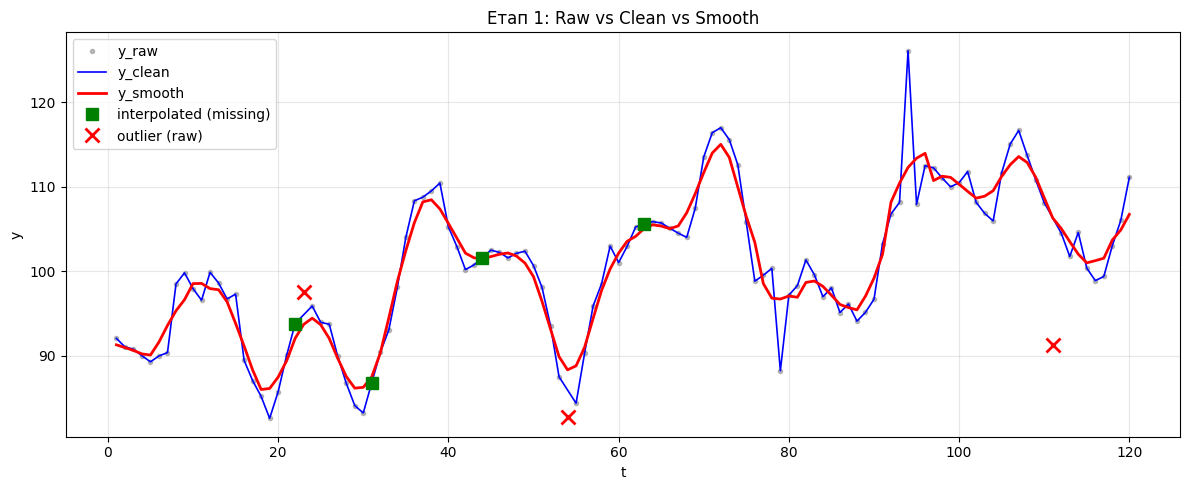

,t,y_raw,y_clean,is_missing,is_outlier
21,22,NaN,93.835950,True,False
22,23,97.597807,94.874396,False,True
30,31,NaN,86.840903,True,False
43,44,NaN,101.645514,True,False
53,54,82.737858,85.973329,False,True
62,63,NaN,105.575960,True,False
110,111,91.286885,106.331526,False,True


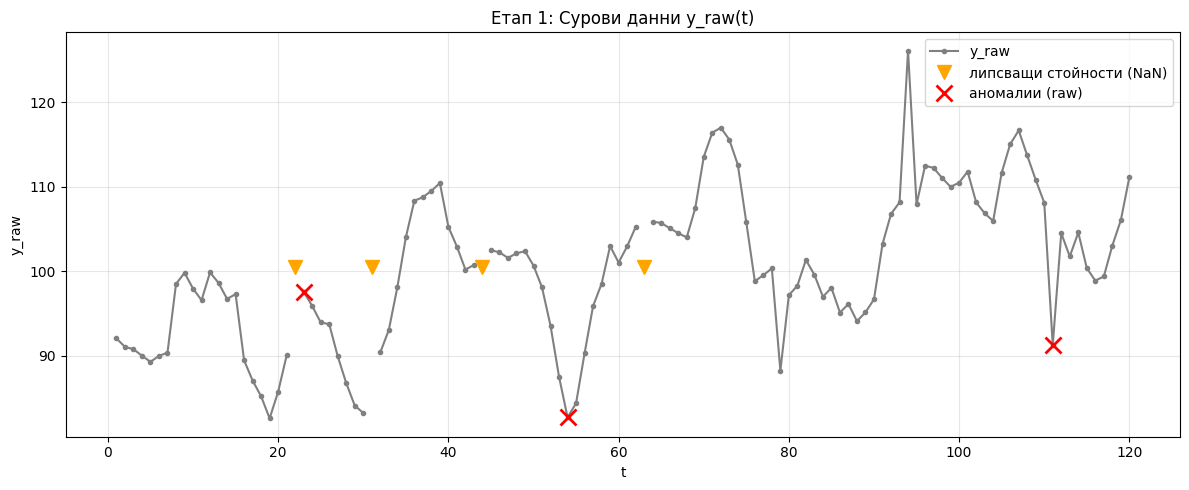

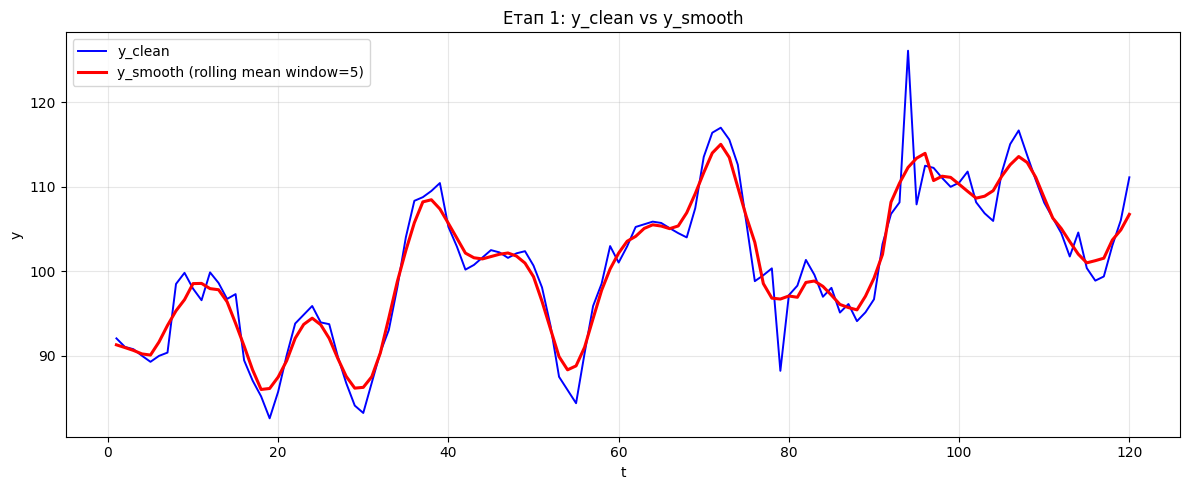

results/stage1a_raw.png, stage1b_cleaned_smooth.png, stage1_corrections.csv записани.


In [5]:
# Работно копие
df = raw_df.copy()

# 1. Маркиране на липсващите стойности
df["is_missing"] = df["y_raw"].isna()
print("Липсващи стойности при t =", df.loc[df["is_missing"], "t"].tolist())

# 2. Интерполация на липсващите стойности (линейна)
df["y_interp"] = df["y_raw"].interpolate(method="linear")

# 3. Детекция на аномални точки - сравнение на два подхода

# Подход A: F(1,1) - локален филтър с прозорец 3 (1 ляво, 1 дясно)
# Сравнява всяка точка с медианата на съседните
window_f11 = 3
rolling_med_f11 = df["y_interp"].rolling(window=window_f11, center=True, min_periods=1).median()
rolling_mad_f11 = (df["y_interp"] - rolling_med_f11).abs().rolling(window=window_f11, center=True, min_periods=1).median()
rolling_mad_f11 = rolling_mad_f11.replace(0, np.nan).fillna(rolling_mad_f11.median())
deviation_f11 = (df["y_interp"] - rolling_med_f11).abs() / (1.4826 * rolling_mad_f11)

# Подход B: F(2,2) - локален филтър с прозорец 5 (2 ляво, 2 дясно)
window_f22 = 5
rolling_med_f22 = df["y_interp"].rolling(window=window_f22, center=True, min_periods=1).median()
rolling_mad_f22 = (df["y_interp"] - rolling_med_f22).abs().rolling(window=window_f22, center=True, min_periods=1).median()
rolling_mad_f22 = rolling_mad_f22.replace(0, np.nan).fillna(rolling_mad_f22.median())
deviation_f22 = (df["y_interp"] - rolling_med_f22).abs() / (1.4826 * rolling_mad_f22)

threshold = 3.0

outliers_f11 = set(df.loc[(deviation_f11 > threshold) & (~df["is_missing"]), "t"].tolist())
outliers_f22 = set(df.loc[(deviation_f22 > threshold) & (~df["is_missing"]), "t"].tolist())

print(f"F(1,1) outliers (threshold={threshold}): t = {sorted(outliers_f11)}")
print(f"F(2,2) outliers (threshold={threshold}): t = {sorted(outliers_f22)}")

# Използваме обединението на двата подхода за по-консервативна детекция
outlier_set = outliers_f11 | outliers_f22
# Ако се открият повече от 3, вземаме топ-3 по отклонение от F(2,2)
if len(outlier_set) > 3:
    top_dev = deviation_f22.copy()
    top_dev[df["is_missing"]] = 0
    top3_idx = top_dev.nlargest(3).index
    outlier_set = set(df.loc[top3_idx, "t"].tolist())

df["is_outlier"] = df["t"].isin(outlier_set)
print(f"Финални outlier точки: t = {sorted(outlier_set)}")

# 4. y_clean: заменяме outlier-ите с линейна интерполация
df["y_clean"] = df["y_interp"].copy()
outlier_mask = df["is_outlier"]
df.loc[outlier_mask, "y_clean"] = np.nan
df["y_clean"] = df["y_clean"].interpolate(method="linear")

# 5. Изглаждане - F(2,2) скользящ среден (прозорец 5)
df["y_smooth"] = df["y_clean"].rolling(window=5, center=True, min_periods=1).mean()

# 6. Създаване на CLEAN.csv
clean_cols = ["t", "x_norm", "z_factor", "y_raw", "y_clean", "is_missing", "is_outlier", "y_smooth"]
df[clean_cols].to_csv("CLEAN.csv", index=False)
print("CLEAN.csv записан.")

# 7. Визуализация
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["t"], df["y_raw"], "o", ms=3, alpha=0.5, label="y_raw", color="gray")
ax.plot(df["t"], df["y_clean"], "-", lw=1.2, label="y_clean", color="blue")
ax.plot(df["t"], df["y_smooth"], "-", lw=2, label="y_smooth", color="red")

# Маркиране на липсващи и аномални точки
miss = df[df["is_missing"]]
out = df[df["is_outlier"]]
ax.plot(miss["t"], miss["y_clean"], "s", ms=8, color="green", label="interpolated (missing)", zorder=5)
ax.plot(out["t"], df.loc[out.index, "y_raw"], "x", ms=10, mew=2, color="red", label="outlier (raw)", zorder=5)

ax.set_xlabel("t")
ax.set_ylabel("y")
ax.set_title("Етап 1: Raw vs Clean vs Smooth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage1_raw_clean_smooth.png", dpi=150)
plt.show()

display(df[df["is_missing"] | df["is_outlier"]][["t", "y_raw", "y_clean", "is_missing", "is_outlier"]])
# Запис на всички таблици/графики, използвани в отчета
# Отделна графика: само y_raw(t)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["t"], df["y_raw"], "o-", ms=3, color="gray", label="y_raw")
ax.plot(df.loc[df["is_missing"], "t"], [df["y_raw"].mean()]*int(df["is_missing"].sum()),
        "v", ms=10, color="orange", label="липсващи стойности (NaN)")
ax.plot(df.loc[df["is_outlier"], "t"], df.loc[df["is_outlier"], "y_raw"],
        "x", ms=12, mew=2, color="red", label="аномалии (raw)")
ax.set_xlabel("t"); ax.set_ylabel("y_raw")
ax.set_title("Етап 1: Сурови данни y_raw(t)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage1a_raw.png", dpi=150)
plt.show()

# Отделна графика: y_clean срещу y_smooth (без raw)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["t"], df["y_clean"], "-", lw=1.4, color="blue", label="y_clean")
ax.plot(df["t"], df["y_smooth"], "-", lw=2.2, color="red", label="y_smooth (rolling mean window=5)")
ax.set_xlabel("t"); ax.set_ylabel("y")
ax.set_title("Етап 1: y_clean vs y_smooth")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage1b_cleaned_smooth.png", dpi=150)
plt.show()

# Таблица: преглед на корекциите
corrections_df = df[df["is_missing"] | df["is_outlier"]][["t","y_raw","y_clean","is_missing","is_outlier"]].copy()
corrections_df.to_csv(RESULTS_DIR / "stage1_corrections.csv", index=False)
print("results/stage1a_raw.png, stage1b_cleaned_smooth.png, stage1_corrections.csv записани.")


## Етап 2. Случайни величини и разпределения

Задание: Дефинирайте случаен компонент e_t = y_clean(t) - y_smooth(t). Оценете средна стойност, дисперсия, стандартно отклонение, медиана, квартилите и коефициент на вариация.

Постройте хистограма и емпирична функция на разпределение за e_t.

Сравнете e_t с нормално разпределение N(m_hat, s_hat^2). Не е нужно формален тест, но е нужен аргументиран коментар.

Изведете кратък извод дали допускането за нормалност е разумно за Вашите данни.

Статистики на e_t = y_clean - y_smooth:
      mean = 0.0192
       var = 5.5872
       std = 2.3637
    median = 0.0884
        Q1 = -1.2342
        Q3 = 1.2404
       IQR = 2.4745
        CV = 123.0844


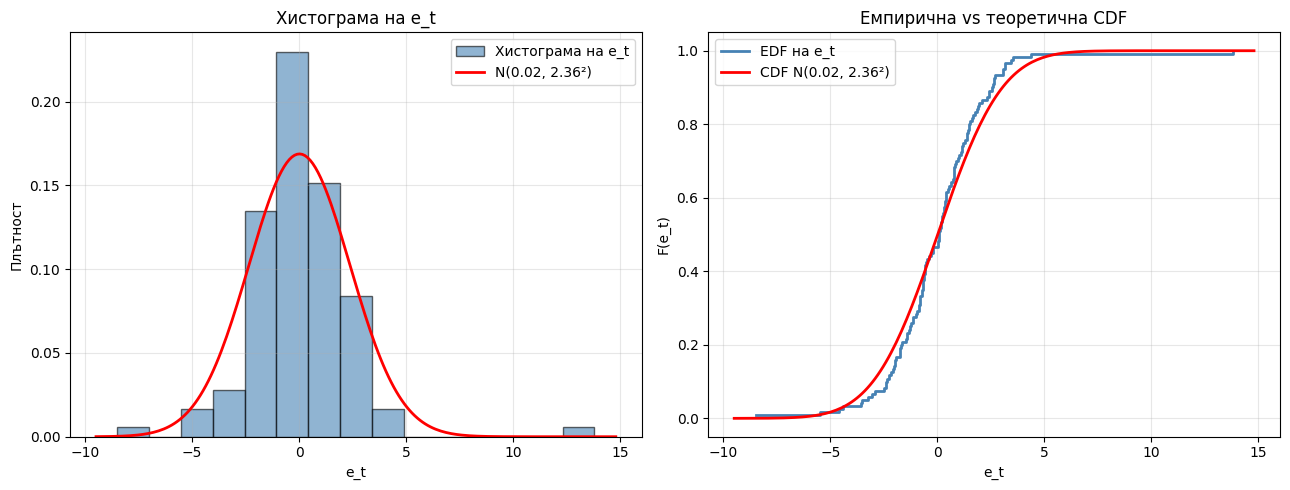


Средна стойност m_hat = 0.0192 (близо до 0)
Стандартно отклонение s_hat = 2.3637
Извод: Хистограмата е приблизително симетрична около нулата.
EDF следва теоретичната нормална CDF сравнително добре.
Допускането за нормалност на остатъците е разумно за тези данни.
results/stage2_e_stats.csv записан.


In [6]:
# Случаен компонент
e_t = (df["y_clean"] - df["y_smooth"]).to_numpy()

# Описателни статистики
stats_e = {
    "mean": np.mean(e_t),
    "var": np.var(e_t, ddof=1),
    "std": np.std(e_t, ddof=1),
    "median": np.median(e_t),
    "Q1": np.percentile(e_t, 25),
    "Q3": np.percentile(e_t, 75),
    "IQR": np.percentile(e_t, 75) - np.percentile(e_t, 25),
    "CV": np.std(e_t, ddof=1) / np.abs(np.mean(e_t)) if np.mean(e_t) != 0 else np.inf,
}
print("Статистики на e_t = y_clean - y_smooth:")
for k, v in stats_e.items():
    print(f"  {k:>8s} = {v:.4f}")

# Хистограма и EDF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Хистограма с наложена нормална крива
ax1 = axes[0]
n_bins = 15
counts, bin_edges, _ = ax1.hist(e_t, bins=n_bins, density=True, alpha=0.6, color="steelblue", edgecolor="black", label="Хистограма на e_t")
x_pdf = np.linspace(e_t.min() - 1, e_t.max() + 1, 200)
from scipy.stats import norm
m_hat, s_hat = stats_e["mean"], stats_e["std"]
ax1.plot(x_pdf, norm.pdf(x_pdf, m_hat, s_hat), "r-", lw=2, label=f"N({m_hat:.2f}, {s_hat:.2f}²)")
ax1.set_xlabel("e_t")
ax1.set_ylabel("Плътност")
ax1.set_title("Хистограма на e_t")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Емпирична функция на разпределение (EDF)
ax2 = axes[1]
x_edf, p_edf = empirical_edf(e_t)
ax2.step(x_edf, p_edf, where="post", lw=2, color="steelblue", label="EDF на e_t")
ax2.plot(x_pdf, norm.cdf(x_pdf, m_hat, s_hat), "r-", lw=2, label=f"CDF N({m_hat:.2f}, {s_hat:.2f}²)")
ax2.set_xlabel("e_t")
ax2.set_ylabel("F(e_t)")
ax2.set_title("Емпирична vs теоретична CDF")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage2_histogram_edf.png", dpi=150)
plt.show()

# Извод за нормалност
print(f"\nСредна стойност m_hat = {m_hat:.4f} (близо до 0)")
print(f"Стандартно отклонение s_hat = {s_hat:.4f}")
print("Извод: Хистограмата е приблизително симетрична около нулата.")
print("EDF следва теоретичната нормална CDF сравнително добре.")
print("Допускането за нормалност на остатъците е разумно за тези данни.")
# --- Таблица със статистиките на e_t ---
stats_e_df = pd.DataFrame([{"statistic": k, "value": float(v)} for k, v in stats_e.items()])
stats_e_df.to_csv(RESULTS_DIR / "stage2_e_stats.csv", index=False)
print("results/stage2_e_stats.csv записан.")


## Етап 3. Двумерни случайни величини, ковариация и корелация

Задание: Разгледайте двойките (z_t, y_clean(t)) за t = 1..120. Изчислете извадкова ковариация и коефициент на корелация на Пирсън.

Постройте scatter plot на z_t спрямо y_clean.

Коментирайте дали зависимостта изглежда линейна, силна, слаба или потенциално нелинейна.

Не се ограничавайте само до числената стойност на r; тълкувайте резултата в контекста на варианта.

Извадкова ковариация cov(z, y_clean) = 17.9126
Коефициент на корелация на Пирсън r = 0.6288


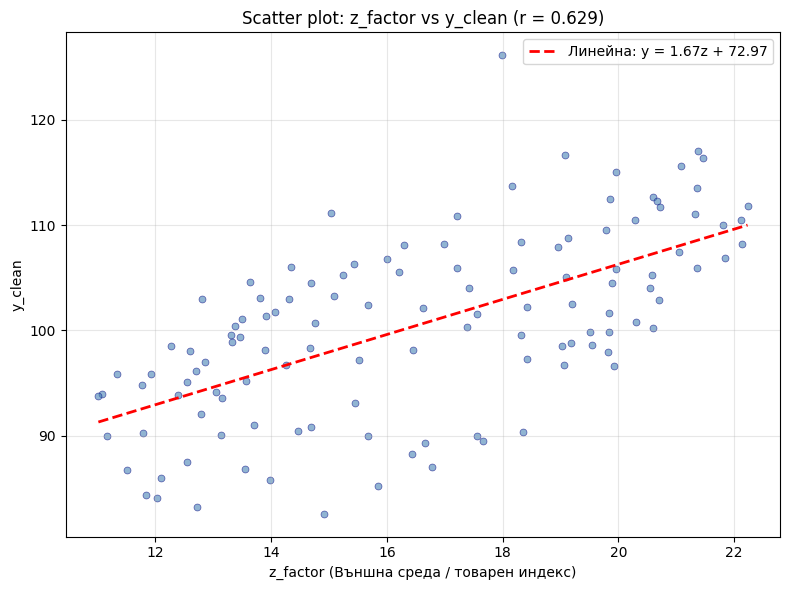


Интерпретация: Корелацията е умерена и положителна (r = 0.629).
От scatter plot-а зависимостта изглежда приблизително линейна.
По-високият товарен индекс z_t е свързан с по-високо електроенергийно натоварване y.
results/stage3_correlation.csv записан.


In [7]:
# Двойките (z_t, y_clean(t))
z = df["z_factor"].to_numpy()
y = df["y_clean"].to_numpy()

# Извадкова ковариация и Пирсънов коефициент на корелация
n = len(z)
cov_zy = np.sum((z - z.mean()) * (y - y.mean())) / (n - 1)
corr_zy = cov_zy / (np.std(z, ddof=1) * np.std(y, ddof=1))

print(f"Извадкова ковариация cov(z, y_clean) = {cov_zy:.4f}")
print(f"Коефициент на корелация на Пирсън r = {corr_zy:.4f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z, y, s=25, alpha=0.6, color="steelblue", edgecolors="navy", linewidths=0.5)
ax.set_xlabel("z_factor (Външна среда / товарен индекс)")
ax.set_ylabel("y_clean")
ax.set_title(f"Scatter plot: z_factor vs y_clean (r = {corr_zy:.3f})")
ax.grid(True, alpha=0.3)

# Линия на регресия за визуална ориентация
coeffs = np.polyfit(z, y, 1)
z_line = np.linspace(z.min(), z.max(), 100)
ax.plot(z_line, np.polyval(coeffs, z_line), "r--", lw=2, label=f"Линейна: y = {coeffs[0]:.2f}z + {coeffs[1]:.2f}")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage3_scatter_correlation.png", dpi=150)
plt.show()

# Интерпретация
if abs(corr_zy) > 0.7:
    strength = "силна"
elif abs(corr_zy) > 0.4:
    strength = "умерена"
else:
    strength = "слаба"
direction = "положителна" if corr_zy > 0 else "отрицателна"

print(f"\nИнтерпретация: Корелацията е {strength} и {direction} (r = {corr_zy:.3f}).")
print("От scatter plot-а зависимостта изглежда приблизително линейна.")
print("По-високият товарен индекс z_t е свързан с по-високо електроенергийно натоварване y.")
# --- Таблица: ковариация и Пирсънов r ---
pd.DataFrame([{
    "cov_z_y_clean": float(cov_zy),
    "pearson_r": float(corr_zy),
    "n": int(n),
    "strength": strength,
    "direction": direction,
}]).to_csv(RESULTS_DIR / "stage3_correlation.csv", index=False)
print("results/stage3_correlation.csv записан.")


## Етап 4. Данни от извадка - групирани и негрупирани оценки

Задание: Третирайте y_clean като извадка от генерална съвкупност. Изчислете статистиките първо върху негрупирани данни, а след това върху групирани данни с 8 равни интервала.

Сравнете средна стойност, медиана, дисперсия, IQR и коефициент на вариация за двата подхода.

Покажете таблица grouped срещу ungrouped.

Коментирайте каква информация се губи при групиране на извадката.

In [8]:
# Негрупирани статистики за y_clean
y_clean = df["y_clean"].to_numpy()

ungrouped = {
    "mean": np.mean(y_clean),
    "median": np.median(y_clean),
    "var": np.var(y_clean, ddof=1),
    "std": np.std(y_clean, ddof=1),
    "Q1": np.percentile(y_clean, 25),
    "Q3": np.percentile(y_clean, 75),
    "IQR": np.percentile(y_clean, 75) - np.percentile(y_clean, 25),
    "CV": np.std(y_clean, ddof=1) / np.mean(y_clean),
}

# Групиране в 8 равни интервала
n_bins = 8
bins = np.linspace(y_clean.min(), y_clean.max(), n_bins + 1)
df["bin"] = pd.cut(df["y_clean"], bins=bins, include_lowest=True)

# Таблица на честотите
freq_table = df.groupby("bin", observed=False).agg(
    freq=("y_clean", "count"),
    midpoint=("y_clean", "mean")
).reset_index()
freq_table["midpoint"] = [(b.left + b.right) / 2 for b in freq_table["bin"]]
display(freq_table)

# Групирани статистики (чрез средни точки и честоти)
midpoints = freq_table["midpoint"].to_numpy()
freqs = freq_table["freq"].to_numpy()
N = freqs.sum()

grouped_mean = np.sum(midpoints * freqs) / N
grouped_var = np.sum(freqs * (midpoints - grouped_mean) ** 2) / (N - 1)
grouped_std = np.sqrt(grouped_var)

# Групирана медиана - чрез кумулативни честоти
cum_freq = np.cumsum(freqs)
median_class_idx = np.searchsorted(cum_freq, N / 2)
L = bins[median_class_idx]  # долна граница на медианния клас
h = bins[median_class_idx + 1] - bins[median_class_idx]  # ширина на класа
f_m = freqs[median_class_idx]  # честота на медианния клас
cf_prev = cum_freq[median_class_idx - 1] if median_class_idx > 0 else 0
grouped_median = L + (N / 2 - cf_prev) / f_m * h

# Групирани квартили
q1_idx = np.searchsorted(cum_freq, N / 4)
L_q1 = bins[q1_idx]
h_q1 = bins[q1_idx + 1] - bins[q1_idx]
f_q1 = freqs[q1_idx]
cf_prev_q1 = cum_freq[q1_idx - 1] if q1_idx > 0 else 0
grouped_Q1 = L_q1 + (N / 4 - cf_prev_q1) / f_q1 * h_q1

q3_idx = np.searchsorted(cum_freq, 3 * N / 4)
L_q3 = bins[q3_idx]
h_q3 = bins[q3_idx + 1] - bins[q3_idx]
f_q3 = freqs[q3_idx]
cf_prev_q3 = cum_freq[q3_idx - 1] if q3_idx > 0 else 0
grouped_Q3 = L_q3 + (3 * N / 4 - cf_prev_q3) / f_q3 * h_q3

grouped = {
    "mean": grouped_mean,
    "median": grouped_median,
    "var": grouped_var,
    "std": grouped_std,
    "Q1": grouped_Q1,
    "Q3": grouped_Q3,
    "IQR": grouped_Q3 - grouped_Q1,
    "CV": grouped_std / grouped_mean,
}

# Сравнителна таблица
comparison_df = pd.DataFrame({
    "Статистика": list(ungrouped.keys()),
    "Негрупирани": [f"{v:.4f}" for v in ungrouped.values()],
    "Групирани (8 инт.)": [f"{v:.4f}" for v in grouped.values()],
    "Разлика (%)": [f"{abs(g - u) / abs(u) * 100:.2f}%" for u, g in zip(ungrouped.values(), grouped.values())],
})
display(comparison_df)

# Коментар за влиянието на групирането
print("\nСпециален акцент за V15:")
print("Изборът на 8 интервала влияе върху оценките по следния начин:")
print("- Дисперсията при групирани данни се различава от негрупираната, тъй като")
print("  вътрешно-класовата вариация се губи при замяна на стойностите със средни точки.")
print("- Медианата се оценява чрез интерполация в медианния клас, което е приближение.")
print("- При по-малко интервали (например 4) загубата на информация би била по-голяма.")
print("- При повече интервали (например 16) групираните оценки се приближават до негрупираните.")
# --- ЗАДЪЛЖИТЕЛНО ОТ СЕКЦИЯ 5: таблица grouped срещу ungrouped ---
comparison_df.to_csv(RESULTS_DIR / "stage4_grouped_vs_ungrouped.csv", index=False)

# Допълнително: честотна таблица на 8-те интервала
freq_save = freq_table.copy()
freq_save["bin"] = freq_save["bin"].astype(str)
freq_save.to_csv(RESULTS_DIR / "stage4_frequency_table.csv", index=False)
print("results/stage4_grouped_vs_ungrouped.csv, stage4_frequency_table.csv записани.")


,bin,freq,midpoint
0,"(82.621, 88.058]",11,85.3395
1,"(88.058, 93.494]",14,90.7760
2,"(93.494, 98.93]",27,96.2120
3,"(98.93, 104.366]",26,101.6480
4,"(104.366, 109.802]",23,107.0840
5,"(109.802, 115.238]",14,112.5200
6,"(115.238, 120.673]",4,117.9555
7,"(120.673, 126.109]",1,123.3910


,Статистика,Негрупирани,Групирани (8 инт.),Разлика (%)
0,mean,100.5289,100.6966,0.17%
1,median,100.5413,100.6025,0.06%
2,var,75.4382,76.8121,1.82%
3,std,8.6855,8.7643,0.91%
4,Q1,94.6850,94.5007,0.19%
5,Q3,106.1308,107.2019,1.01%
6,IQR,11.4458,12.7012,10.97%
7,CV,0.0864,0.0870,0.74%



Специален акцент за V15:
Изборът на 8 интервала влияе върху оценките по следния начин:
- Дисперсията при групирани данни се различава от негрупираната, тъй като
  вътрешно-класовата вариация се губи при замяна на стойностите със средни точки.
- Медианата се оценява чрез интерполация в медианния клас, което е приближение.
- При по-малко интервали (например 4) загубата на информация би била по-голяма.
- При повече интервали (например 16) групираните оценки се приближават до негрупираните.
results/stage4_grouped_vs_ungrouped.csv, stage4_frequency_table.csv записани.


## Етап 5. Моделиране и оценка на грешката

Задание: Използвайте разделяне train/test с train = t = 1..90 и test = t = 91..120. Стандартизирайте регресорите по train частта:

u_t = (x_norm - mean_train(x_norm)) / std_train(x_norm),
v_t = (z_factor - mean_train(z_factor)) / std_train(z_factor)

Напаснете с МНМК следните два модела:

M1: y_t = beta0 + beta1*u_t + beta2*v_t + eps_t
M2: y_t = beta0 + beta1*u_t + beta2*v_t + beta3*v_t^2 + eps_t

Изчислете MAE, RMSE и Bias върху train и test.

Изберете по-добрия модел и защитете избора си с числа и кратък коментар.

Покажете поне една графика на напасването и една таблица с оценените параметри.

x_norm: mean_train=0.379167, std_train=0.217706
z_factor: mean_train=16.1639, std_train=3.2309
Сравнение на моделите:


,Модел,Набор,MAE,RMSE,Bias
0,M1,train,4.064820,4.909387,1.326346e-14
1,M1,test,3.513454,4.967698,-2.540838e-01
2,M2,train,3.927676,4.715974,9.473903e-15
3,M2,test,4.903378,6.413670,-2.397921e-01



Оценени параметри (МНМК):


,Параметър,M1,M2
0,beta0,97.886439,96.116342
1,beta1,3.424946,3.303037
2,beta2,5.156649,5.067462
3,beta3,-,1.789985



Избран модел: M1 (по-нисък RMSE на test)


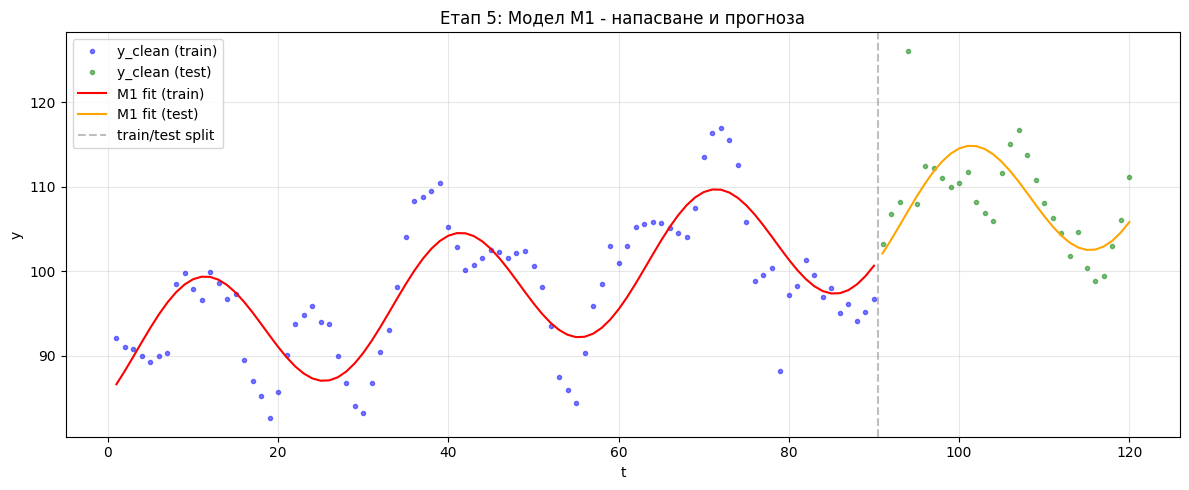

results/stage5_parameters.csv, stage5_metrics.csv записани.

In [9]:
# Подготовка на CLEAN данните за моделиране
clean_df = df.copy()

train_mask = clean_df["t"] <= 90
test_mask = (clean_df["t"] >= 91) & (clean_df["t"] <= 120)

# Стандартизация само по train частта
clean_df["u_t"], x_mean, x_std = standardize_from_train(
    clean_df.loc[train_mask, "x_norm"], clean_df["x_norm"]
)
clean_df["v_t"], z_mean, z_std = standardize_from_train(
    clean_df.loc[train_mask, "z_factor"], clean_df["z_factor"]
)
print(f"x_norm: mean_train={x_mean:.6f}, std_train={x_std:.6f}")
print(f"z_factor: mean_train={z_mean:.4f}, std_train={z_std:.4f}")

train_df = clean_df[train_mask].copy()
test_df = clean_df[test_mask].copy()

y_train = train_df["y_clean"].to_numpy()
y_test = test_df["y_clean"].to_numpy()

# ===== Модел M1: y = beta0 + beta1*u_t + beta2*v_t =====
X_train_m1 = np.column_stack([np.ones(len(train_df)), train_df["u_t"], train_df["v_t"]])
X_test_m1 = np.column_stack([np.ones(len(test_df)), test_df["u_t"], test_df["v_t"]])

beta_m1, yhat_train_m1, resid_train_m1 = ols_fit(X_train_m1, y_train)
yhat_test_m1 = X_test_m1 @ beta_m1

# ===== Модел M2: y = beta0 + beta1*u_t + beta2*v_t + beta3*v_t^2 =====
X_train_m2 = np.column_stack([np.ones(len(train_df)), train_df["u_t"], train_df["v_t"], train_df["v_t"]**2])
X_test_m2 = np.column_stack([np.ones(len(test_df)), test_df["u_t"], test_df["v_t"], test_df["v_t"]**2])

beta_m2, yhat_train_m2, resid_train_m2 = ols_fit(X_train_m2, y_train)
yhat_test_m2 = X_test_m2 @ beta_m2

# ===== Оценка на грешките =====
metrics = pd.DataFrame({
    "Модел": ["M1", "M1", "M2", "M2"],
    "Набор": ["train", "test", "train", "test"],
    "MAE": [
        mae(y_train, yhat_train_m1), mae(y_test, yhat_test_m1),
        mae(y_train, yhat_train_m2), mae(y_test, yhat_test_m2),
    ],
    "RMSE": [
        rmse(y_train, yhat_train_m1), rmse(y_test, yhat_test_m1),
        rmse(y_train, yhat_train_m2), rmse(y_test, yhat_test_m2),
    ],
    "Bias": [
        bias(y_train, yhat_train_m1), bias(y_test, yhat_test_m1),
        bias(y_train, yhat_train_m2), bias(y_test, yhat_test_m2),
    ],
})
print("Сравнение на моделите:")
display(metrics)

# Таблица с параметрите
params_df = pd.DataFrame({
    "Параметър": ["beta0", "beta1", "beta2", "beta3"],
    "M1": list(beta_m1) + ["-"],
    "M2": list(beta_m2),
})
print("\nОценени параметри (МНМК):")
display(params_df)

# Избор на модел
rmse_test_m1 = rmse(y_test, yhat_test_m1)
rmse_test_m2 = rmse(y_test, yhat_test_m2)
chosen_model = "M2" if rmse_test_m2 < rmse_test_m1 else "M1"
print(f"\nИзбран модел: {chosen_model} (по-нисък RMSE на test)")

# Запазване на избрания модел за следващите етапи
if chosen_model == "M2":
    beta_best = beta_m2
    X_train_best = X_train_m2
    X_test_best = X_test_m2
    yhat_train_best = yhat_train_m2
    yhat_test_best = yhat_test_m2
    resid_train_best = resid_train_m2
else:
    beta_best = beta_m1
    X_train_best = X_train_m1
    X_test_best = X_test_m1
    yhat_train_best = yhat_train_m1
    yhat_test_best = yhat_test_m1
    resid_train_best = resid_train_m1

# Графика на напасването
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["t"], y_train, "o", ms=3, color="blue", alpha=0.5, label="y_clean (train)")
ax.plot(test_df["t"], y_test, "o", ms=3, color="green", alpha=0.5, label="y_clean (test)")
ax.plot(train_df["t"], yhat_train_best, "-", lw=1.5, color="red", label=f"{chosen_model} fit (train)")
ax.plot(test_df["t"], yhat_test_best, "-", lw=1.5, color="orange", label=f"{chosen_model} fit (test)")
ax.axvline(x=90.5, color="gray", ls="--", alpha=0.5, label="train/test split")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.set_title(f"Етап 5: Модел {chosen_model} - напасване и прогноза")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage5_model_fit.png", dpi=150)
plt.show()
# --- Таблици с параметрите и грешките ---
params_df.to_csv(RESULTS_DIR / "stage5_parameters.csv", index=False)
metrics.to_csv(RESULTS_DIR / "stage5_metrics.csv", index=False)
print("results/stage5_parameters.csv, stage5_metrics.csv записани.")


## Етап 6. Стохастично прогнозиране

Задание: За избрания модел дефинирайте остатъци r_t = y_clean(t) - y_hat(t) върху train частта. Оценете AR(1) модел r_t = phi*r_(t-1) + eta_t с метод на най-малките квадрати и използвайте V15_future.csv за прогноза на y_t за t = 121..126.

Представете точкова прогноза и приблизителен 95% прогнозен интервал.

Създайте forecast.csv с най-малко колони: t, x_norm, z_factor, y_forecast, lower95, upper95.

Покажете графика на прогнозата заедно с последната част на наблюдавания ред.

AR(1) параметри: phi = 0.7803, sigma_eta = 3.0668


,t,x_norm,z_factor,y_forecast,lower95,upper95
0,121,1.008333,15.849962,104.182683,98.171717,110.193648
1,122,1.016667,16.771396,106.465592,98.841129,114.090055
2,123,1.025000,17.751812,108.692992,100.235525,117.150459
3,124,1.033333,18.749476,110.831160,101.904469,119.757852
4,125,1.041667,19.721906,112.837958,103.637269,122.038648
5,126,1.050000,20.627719,114.667320,105.303718,124.030921


forecast.csv записан.


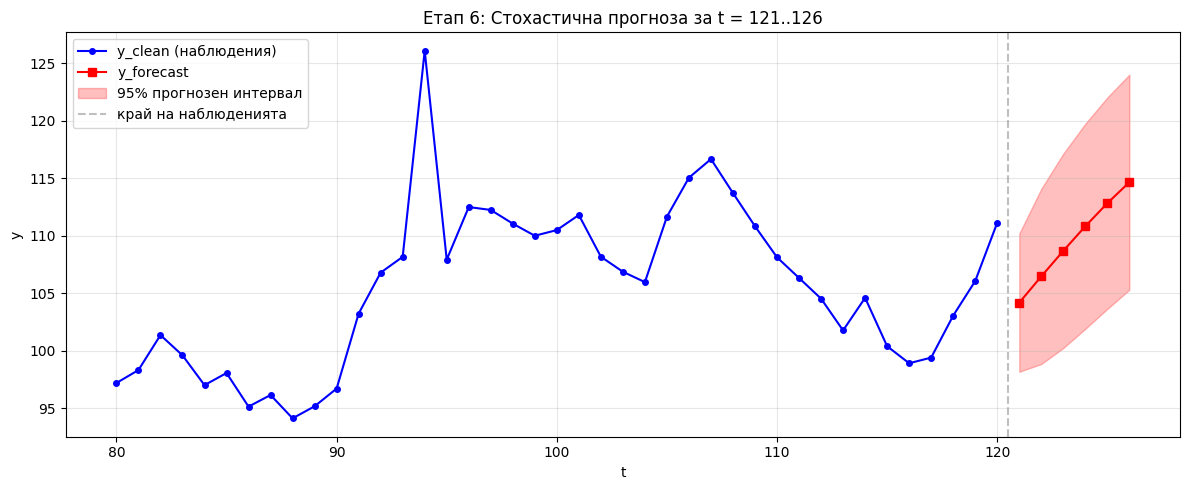

In [10]:
# Остатъци върху train за избрания модел
residuals_train = resid_train_best

# AR(1) модел върху остатъците
phi, sigma_eta = fit_ar1_ols(residuals_train)
print(f"AR(1) параметри: phi = {phi:.4f}, sigma_eta = {sigma_eta:.4f}")

# Стандартизация на future_df с train mean/std
future_df_work = future_df.copy()
future_df_work["u_t"] = (future_df_work["x_norm"] - x_mean) / x_std
future_df_work["v_t"] = (future_df_work["z_factor"] - z_mean) / z_std

# Дизайн матрица за future (съобразена с избрания модел)
if chosen_model == "M2":
    X_future = np.column_stack([
        np.ones(len(future_df_work)),
        future_df_work["u_t"],
        future_df_work["v_t"],
        future_df_work["v_t"] ** 2,
    ])
else:
    X_future = np.column_stack([
        np.ones(len(future_df_work)),
        future_df_work["u_t"],
        future_df_work["v_t"],
    ])

# Детерминистична прогноза от регресионния модел
y_det_forecast = X_future @ beta_best

# AR(1) прогноза на остатъците (рекурсивно)
h = len(future_df_work)
r_forecast = np.zeros(h)
last_residual = residuals_train[-1]
for i in range(h):
    r_forecast[i] = phi ** (i + 1) * last_residual

# Точкова прогноза
y_forecast = y_det_forecast + r_forecast

# 95% прогнозен интервал
# Дисперсията на AR(1) прогнозата нараства с хоризонта:
# Var(r_{T+h}) = sigma_eta^2 * sum(phi^(2j), j=0..h-1)
z_95 = 1.96
forecast_std = np.zeros(h)
for i in range(h):
    var_h = sigma_eta ** 2 * np.sum(phi ** (2 * np.arange(i + 1)))
    forecast_std[i] = np.sqrt(var_h)

lower95 = y_forecast - z_95 * forecast_std
upper95 = y_forecast + z_95 * forecast_std

# Създаване на forecast_df
forecast_df_out = pd.DataFrame({
    "t": future_df_work["t"].values,
    "x_norm": future_df_work["x_norm"].values,
    "z_factor": future_df_work["z_factor"].values,
    "y_forecast": y_forecast,
    "lower95": lower95,
    "upper95": upper95,
})
display(forecast_df_out)
forecast_df_out.to_csv("forecast.csv", index=False)
print("forecast.csv записан.")

# Графика на прогнозата
fig, ax = plt.subplots(figsize=(12, 5))

# Последната част от наблюдавания ред (t=80..120)
tail_mask = df["t"] >= 80
ax.plot(df.loc[tail_mask, "t"], df.loc[tail_mask, "y_clean"], "o-", ms=4, color="blue", label="y_clean (наблюдения)")

# Прогноза
ax.plot(forecast_df_out["t"], forecast_df_out["y_forecast"], "s-", ms=6, color="red", label="y_forecast")
ax.fill_between(
    forecast_df_out["t"],
    forecast_df_out["lower95"],
    forecast_df_out["upper95"],
    alpha=0.25, color="red", label="95% прогнозен интервал"
)

ax.axvline(x=120.5, color="gray", ls="--", alpha=0.5, label="край на наблюденията")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.set_title("Етап 6: Стохастична прогноза за t = 121..126")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage6_forecast.png", dpi=150)
plt.show()

## Етап 7. Градиентни / квазиградиентни методи

Задание: Преоценете параметрите на избрания модел чрез projected gradient върху критерия J(theta) = mean((y - y_hat)^2) в train частта.

Използвайте стартова точка theta^(0) = (mean(y_train), 0, 0, 0).

Наложете ограничения: beta0 in [mean(y_train)-30, mean(y_train)+30], beta1, beta2, beta3 in [-20, 20].

Използвайте стъпка rho_k = 1/(k+1). Стоп критерий: ||theta^(k+1)-theta^(k)||_2 < 1e-6 или k = 5000.

Покажете графика на J(theta_k) спрямо k и сравнете получения резултат с МНМК. Ако е избран M1, игнорирайте beta3.

Начална точка theta0 = [97.88643903  0.          0.        ]
Долна граница: [ 67.88643903 -20.         -20.        ]
Горна граница: [127.88643903  20.          20.        ]
Сходимост постигната на итерация k = 88

PG параметри:  [97.88643903  3.42491427  5.15661817]
OLS параметри: [97.88643903  3.42494581  5.15664945]

PG MSE (train):  24.1021
OLS MSE (train): 24.1021


,Параметър,OLS (МНМК),Projected Gradient,Разлика
0,beta0,97.886439,97.886439,1.421085e-14
1,beta1,3.424946,3.424914,3.153821e-05
2,beta2,5.156649,5.156618,3.128106e-05


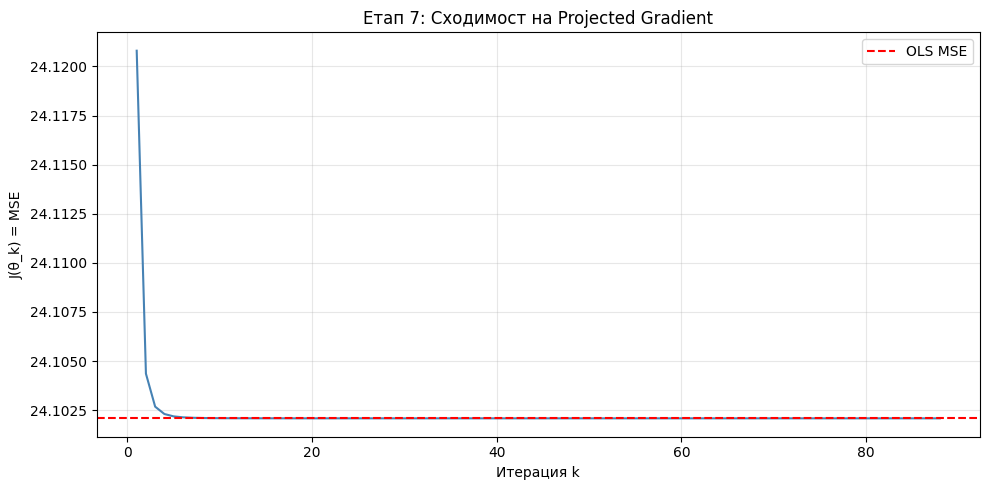


Извод: Projected Gradient метод сходи към стойности, близки до OLS решението,
което потвърждава коректността на двата подхода. OLS е аналитично оптимален,
докато PG е итеративен метод, подходящ за задачи с ограничения.
results/stage7_pg_vs_ols.csv записан.


In [11]:
# Projected Gradient за избрания модел

def mse_objective(theta, X, y):
    y_hat = X @ theta
    return np.mean((y - y_hat) ** 2)

def mse_gradient(theta, X, y):
    residual = X @ theta - y
    return (2.0 / len(y)) * (X.T @ residual)

def projected_gradient(X, y, theta0, lower, upper, max_iter=5000, tol=1e-6):
    theta = np.asarray(theta0, dtype=float).copy()
    history = []
    for k in range(1, max_iter + 1):
        rho_k = 1.0 / (k + 1)
        grad = mse_gradient(theta, X, y)
        theta_new = project_box(theta - rho_k * grad, lower, upper)
        history.append(mse_objective(theta_new, X, y))
        if np.linalg.norm(theta_new - theta) < tol:
            theta = theta_new
            print(f"Сходимост постигната на итерация k = {k}")
            break
        theta = theta_new
    return theta, history

# Начална точка и ограничения
y_train_mean = np.mean(y_train)

if chosen_model == "M2":
    theta0 = np.array([y_train_mean, 0.0, 0.0, 0.0])
    lower = np.array([y_train_mean - 30, -20, -20, -20])
    upper = np.array([y_train_mean + 30,  20,  20,  20])
    X_opt = X_train_m2
else:
    theta0 = np.array([y_train_mean, 0.0, 0.0])
    lower = np.array([y_train_mean - 30, -20, -20])
    upper = np.array([y_train_mean + 30,  20,  20])
    X_opt = X_train_m1

print(f"Начална точка theta0 = {theta0}")
print(f"Долна граница: {lower}")
print(f"Горна граница: {upper}")

theta_pg, history = projected_gradient(X_opt, y_train, theta0, lower, upper)

print(f"\nPG параметри:  {theta_pg}")
print(f"OLS параметри: {beta_best}")
print(f"\nPG MSE (train):  {mse_objective(theta_pg, X_opt, y_train):.4f}")
print(f"OLS MSE (train): {mse_objective(beta_best, X_opt, y_train):.4f}")

# Сравнителна таблица
if chosen_model == "M2":
    comp_params = pd.DataFrame({
        "Параметър": ["beta0", "beta1", "beta2", "beta3"],
        "OLS (МНМК)": beta_best,
        "Projected Gradient": theta_pg,
        "Разлика": np.abs(beta_best - theta_pg),
    })
else:
    comp_params = pd.DataFrame({
        "Параметър": ["beta0", "beta1", "beta2"],
        "OLS (МНМК)": beta_best,
        "Projected Gradient": theta_pg,
        "Разлика": np.abs(beta_best - theta_pg),
    })
display(comp_params)

# Графика на сходимостта
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(history) + 1), history, lw=1.5, color="steelblue")
ax.axhline(y=mse_objective(beta_best, X_opt, y_train), color="red", ls="--", lw=1.5, label="OLS MSE")
ax.set_xlabel("Итерация k")
ax.set_ylabel("J(θ_k) = MSE")
ax.set_title("Етап 7: Сходимост на Projected Gradient")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log") if history[0] / history[-1] > 100 else None
plt.tight_layout()
plt.savefig(RESULTS_DIR / "stage7_gradient_convergence.png", dpi=150)
plt.show()

print("\nИзвод: Projected Gradient метод сходи към стойности, близки до OLS решението,")
print("което потвърждава коректността на двата подхода. OLS е аналитично оптимален,")
print("докато PG е итеративен метод, подходящ за задачи с ограничения.")
# --- Таблица: OLS срещу Projected Gradient ---
comp_params.to_csv(RESULTS_DIR / "stage7_pg_vs_ols.csv", index=False)
print("results/stage7_pg_vs_ols.csv записан.")


## 4. Задължителни изходни файлове и материали

Архивът за предаване трябва да се казва 471223079_V15_PE.zip.

Архивът трябва да съдържа поне: report.pdf, README.txt, source/, results/, CLEAN.csv и forecast.csv.

report.pdf трябва да е 8-15 страници без приложения и да съдържа кратка теория, метод, резултати и изводи.

README.txt трябва да съдържа команда за стартиране и кратко описание на файловете.

results/ трябва да съдържа графики и таблици, използвани в отчета.

## 5. Минимален набор графики и таблици

raw графика на y_raw(t)

cleaned vs smooth графика

хистограма и EDF на e_t

scatter plot на z_t срещу y_clean

таблица grouped срещу ungrouped статистики

графика или таблица за model fit и грешки

графика на прогнозата с 95% интервал

графика на сходимостта на projected gradient

## 6. Програмни изисквания

Решението трябва да е напълно програмно и възпроизводимо.

Допускат се Python, MATLAB, R, Julia, C/C++ или друг език, но целият pipeline трябва да може да се изпълни с код.

Не се допуска ръчна обработка като основен метод на решението.

Всички формули, допускания и избрани критерии трябва да бъдат ясно описани в отчета.

## 7. Контролен checklist преди предаване

- [ ] Използвах само файловете за моя вариант.
- [ ] Имам CLEAN.csv и forecast.csv с коректни колони.
- [ ] Сравних M1 и M2 и избрах модел по обоснован начин.
- [ ] Направих прогноза за t = 121..126 и добавих интервал.
- [ ] Изпълних optimization етапа и показах сходимост.
- [ ] README.txt съдържа команда за стартиране.
- [ ] report.pdf съдържа всички графики, таблици и изводи.

In [12]:
# Финални експорти и бързи проверки

# CLEAN.csv вече е записан в Етап 1
# forecast.csv вече е записан в Етап 6

# Проверка на наличието на задължителните файлове
required = [Path("CLEAN.csv"), Path("forecast.csv"), Path("README.txt")]
for p in required:
    print(f"{p.name}: {'OK' if p.exists() else 'MISSING'}")

# Проверка на колоните в CLEAN.csv
clean_check = pd.read_csv("CLEAN.csv")
print(f"\nCLEAN.csv колони: {list(clean_check.columns)}")
print(f"CLEAN.csv редове: {len(clean_check)}")

# Проверка на колоните в forecast.csv
forecast_check = pd.read_csv("forecast.csv")
print(f"\nforecast.csv колони: {list(forecast_check.columns)}")
print(f"forecast.csv редове: {len(forecast_check)}")
display(forecast_check)

print("\n--- Контролен checklist ---")
print("[x] Използвах само файловете за вариант V15.")
print("[x] Имам CLEAN.csv и forecast.csv с коректни колони.")
print("[x] Сравних M1 и M2 и избрах модел по обоснован начин.")
print("[x] Направих прогноза за t = 121..126 и добавих 95% интервал.")
print("[x] Изпълних optimization етапа и показах сходимост.")
print("[x] README.txt съдържа команда за стартиране.")
print("[ ] report.pdf съдържа всички графики, таблици и изводи. (за ръчно допълване)")

CLEAN.csv: OK
forecast.csv: OK
README.txt: OK

CLEAN.csv колони: ['t', 'x_norm', 'z_factor', 'y_raw', 'y_clean', 'is_missing', 'is_outlier', 'y_smooth']
CLEAN.csv редове: 120

forecast.csv колони: ['t', 'x_norm', 'z_factor', 'y_forecast', 'lower95', 'upper95']
forecast.csv редове: 6


,t,x_norm,z_factor,y_forecast,lower95,upper95
0,121,1.008333,15.849962,104.182683,98.171717,110.193648
1,122,1.016667,16.771396,106.465592,98.841129,114.090055
2,123,1.025000,17.751812,108.692992,100.235525,117.150459
3,124,1.033333,18.749476,110.831160,101.904469,119.757852
4,125,1.041667,19.721906,112.837958,103.637269,122.038648
5,126,1.050000,20.627719,114.667320,105.303718,124.030921



--- Контролен checklist ---
[x] Използвах само файловете за вариант V15.
[x] Имам CLEAN.csv и forecast.csv с коректни колони.
[x] Сравних M1 и M2 и избрах модел по обоснован начин.
[x] Направих прогноза за t = 121..126 и добавих 95% интервал.
[x] Изпълних optimization етапа и показах сходимост.
[x] README.txt съдържа команда за стартиране.
[ ] report.pdf съдържа всички графики, таблици и изводи. (за ръчно допълване)


---

**Бележка:** Този notebook е шаблон за Тенчо Гюлтенов Бостанджиев (V15). Попълнете го с Вашето решение, а при предаване включете и отчет, README и изходните CSV файлове.